# Detección de provincias a partir de universidades en títulos del BOE

En este notebook identificamos la provincia (y posteriormente la comunidad autónoma) correspondiente a cada disposición universitaria publicada en el BOE.  
Para ello, utilizamos coincidencias textuales, alias, siglas, coincidencias difusas (*fuzzy matching*) y similitud semántica mediante *Sentence Transformers*.


## Instalación de librerías necesarias

Instalamos las dependencias requeridas para el procesamiento de texto, coincidencias y embeddings semánticos.


In [215]:
!pip install unidecode rapidfuzz sentence-transformers spacy

# Descargar modelo spaCy español
!python -m spacy download es_core_news_md


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 23.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [216]:
import pandas as pd
import numpy as np
import re
import unidecode
from rapidfuzz import fuzz, process
from sentence_transformers import SentenceTransformer, util
from multiprocessing import Pool, cpu_count
import spacy
from spacy.matcher import PhraseMatcher


## Carga y preprocesamiento del dataset

Cargamos el dataset procesado con títulos normalizados (`Titulo_Semantico`) y preparamos funciones de normalización
para eliminar tildes, mayúsculas, signos y variantes lingüísticas (e.g., *universitat* → *universidad*).


In [217]:
df = pd.read_csv("dataset_universidades_procesado.csv")
df['Titulo_Semantico'] = df['Titulo_Semantico'].fillna('')

nlp = spacy.load("es_core_news_md", disable=["parser", "tagger", "lemmatizer"])


In [218]:
def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = unidecode.unidecode(texto)
    texto = re.sub(r'[«»"“”]', '', texto)
    texto = re.sub(r'[-–—]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto)
    texto = re.sub(r'\b(universitat|universidade)\b', 'universidad', texto)
    return texto.strip()


## Definición del mapeo universidad–provincia

Creamos un diccionario que asocia cada provincia española con las universidades cuya sede principal se encuentra allí.

> En universidades con campus en varias provincias, solo consideramos la sede principal para evitar asignaciones múltiples (por ejemplo, la Universidad de Santiago de Compostela se asocia a A Coruña, aunque tenga presencia en Lugo y Ourense).

También definimos alias y siglas frecuentes (como *UPM*, *UAB*, *UNED*) para mejorar la detección.


In [219]:
universidades_por_provincia = {
    # --- ANDALUCÍA ---
    "Sevilla": ["Universidad de Sevilla", "Universidad Pablo de Olavide", "Universidad Internacional de Andalucía"],
    "Granada": ["Universidad de Granada"],
    "Córdoba": ["Universidad de Córdoba", "Universidad Loyola Andalucía"],
    "Málaga": ["Universidad de Málaga"],
    "Cádiz": ["Universidad de Cádiz"],
    "Almería": ["Universidad de Almería"],
    "Huelva": ["Universidad de Huelva"],
    "Jaén": ["Universidad de Jaén"],

    # --- ARAGÓN ---
    "Zaragoza": ["Universidad de Zaragoza", "Universidad San Jorge"],

    # --- ASTURIAS ---
    "Asturias": ["Universidad de Oviedo"],

    # --- ISLAS BALEARES ---
    "Islas Baleares": ["Universidad de las Islas Baleares"],

    # --- CANARIAS ---
    "Santa Cruz de Tenerife": ["Universidad de La Laguna"],
    "Las Palmas": ["Universidad de Las Palmas de Gran Canaria"],

    # --- CANTABRIA ---
    "Cantabria": ["Universidad de Cantabria", "Universidad Europea del Atlántico"],

    # --- CASTILLA Y LEÓN ---
    "Salamanca": ["Universidad de Salamanca", "Universidad Pontificia de Salamanca"],
    "Valladolid": ["Universidad de Valladolid", "IE University"],
    "León": ["Universidad de León"],
    "Burgos": ["Universidad de Burgos"],
    "Ávila": ["Universidad Católica de Ávila"],

    # --- CASTILLA-LA MANCHA ---
    #"Toledo": ["Universidad de Castilla-La Mancha"],
    "Ciudad Real": ["Universidad de Castilla-La Mancha"],
    #"Albacete": ["Universidad de Castilla-La Mancha"],
    #"Cuenca": ["Universidad de Castilla-La Mancha"],
    #"Guadalajara": ["Universidad de Castilla-La Mancha"],

    # --- CATALUÑA ---
    "Barcelona": [
        "Universidad de Barcelona",
        "Universidad Autónoma de Barcelona",
        "Universidad Politécnica de Cataluña",
        "Universidad Pompeu Fabra",
        "Universidad Oberta de Cataluña",
        "Universidad Internacional de Cataluña",
        "Universidad Abat Oliba CEU",
        "Universidad Ramon Llull",
        "Serveis Universitaris de Catalunya",
        "Universitat Politècnica de Catalunya"
    ],
    "Girona": ["Universidad de Girona"],
    "Lleida": ["Universidad de Lleida"],
    "Tarragona": ["Universidad Rovira i Virgili"],

    # --- COMUNIDAD VALENCIANA ---
    "Valencia": [
        "Universidad de Valencia",
        "Universidad Politécnica de Valencia",
        "Universidad Católica de Valencia San Vicente Mártir",
        "Universidad CEU Cardenal Herrera"
    ],
    "Alicante": ["Universidad de Alicante", "Universidad Miguel Hernández de Elche"],
    "Castellón": ["Universidad Jaume I"],

    # --- EXTREMADURA ---
    "Badajoz": ["Universidad de Extremadura"],
    #"Cáceres": ["Universidad de Extremadura"],

    # --- GALICIA ---
    "A Coruña": ["Universidad de A Coruña", "Universidad de Santiago de Compostela"],
    "Pontevedra": ["Universidad de Vigo", "UNED"],

    # --- MADRID ---
    "Madrid": [
        "Universidad Complutense de Madrid",
        "Universidad Politécnica de Madrid",
        "Universidad Autónoma de Madrid",
        "Universidad de Alcalá",
        "Universidad Rey Juan Carlos",
        "Universidad San Pablo CEU",
        "Universidad Pontificia Comillas",
        "Universidad Europea de Madrid",
        "Universidad Camilo José Cela",
        "Universidad Nebrija",
        "Universidad a Distancia de Madrid",
        "Universidad Francisco de Vitoria",
        "IE Universidad"],

    # --- MURCIA ---
    "Murcia": ["Universidad de Murcia", "Universidad Católica San Antonio de Murcia", "Universidad Politécnica de Cartagena"],

    # --- NAVARRA ---
    "Navarra": ["Universidad de Navarra", "Universidad Pública de Navarra"],

    # --- PAÍS VASCO ---
    "Bizkaia": ["Universidad de Deusto", "Universidad del País Vasco", "Universidad de País Vasco/Euskal Herriko Unibertsitatea"
                , "Universidad del País Vasco UPV/EHU", "Universidad del País Vasco (UPV/EHU)"],
    "Gipuzkoa": ["Universidad de Mondragón"],

    # --- LA RIOJA ---
    "La Rioja": ["Universidad de La Rioja", "Universidad Internacional de La Rioja", "Escuela de Ingeniería Técnica Industrial de Logroño"]
}


# Normalizar todas
universidades_por_provincia_norm = {
    prov: [normalizar_texto(u) for u in unis]
    for prov, unis in universidades_por_provincia.items()
}


In [220]:
siglas = {
    "uned": "Universidad Nacional de Educación a Distancia",
    "upm": "Universidad Politécnica de Madrid",
    "uax": "Universidad Alfonso X el Sabio",
    "uab": "Universidad Autónoma de Barcelona",
    "uam": "Universidad Autónoma de Madrid",
    "ub": "Universidad de Barcelona",
    "us": "Universidad de Sevilla",
    "ucm": "Universidad Complutense de Madrid",
    "uv": "Universidad de Valencia",
    "urjc": "Universidad Rey Juan Carlos",
    "upv": "Universidad Politécnica de Valencia",
    "uc3m": "Universidad Carlos III de Madrid",
    "udc": "Universidad de A Coruña",
    "uoc": "Universidad Oberta de Cataluña",
    "ud": "Universidad de Deusto"
}

alias = {
    "universitat de barcelona": "Universidad de Barcelona",
    "universitat de valencia": "Universidad de Valencia",
    "universitat politècnica de valencia": "Universidad Politécnica de Valencia",
    "universitat de girona": "Universidad de Girona",
    "universidade da coruña": "Universidad de A Coruña",
    "universidade de santiago de compostela": "Universidad de Santiago de Compostela"
}

alias_norm = {normalizar_texto(k): normalizar_texto(v) for k, v in alias.items()}
siglas_re = {re.compile(rf"\b{sig}\b"): normalizar_texto(nombre) for sig, nombre in siglas.items()}


In [221]:
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
patterns = [nlp.make_doc(u.lower()) for ulist in universidades_por_provincia.values() for u in ulist]
matcher.add("UNIS", patterns)

model_sem = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
todas_unis = [u for lista in universidades_por_provincia.values() for u in lista]
todas_unis_norm = [normalizar_texto(u) for u in todas_unis]
todas_unis_embs = model_sem.encode(todas_unis_norm, convert_to_tensor=True)


## Detección avanzada de provincias en títulos universitarios

Para cada título del BOE:
1. Buscamos coincidencias textuales exactas con el nombre de universidades.
2. Comprobamos alias y siglas conocidas.
3. Si no se encuentra coincidencia directa, buscamos el nombre de la provincia en el texto.
4. Aplicamos *fuzzy matching* si sigue sin detectarse.
5. Finalmente, usamos similitud semántica con `SentenceTransformer`.

El resultado es una matriz binaria que indica con `1` si una universidad (por tanto, provincia) ha sido detectada en cada disposición.


In [222]:
def detectar_provincia(titulo):
    titulo_norm = normalizar_texto(titulo)
    detectadas = {prov: 0 for prov in universidades_por_provincia}

    # Coincidencia directa
    for prov, unis in universidades_por_provincia_norm.items():
        for uni in unis:
            if uni in titulo_norm:
                detectadas[prov] = 1
                break

    # Alias
    for k, v in alias_norm.items():
        if k in titulo_norm:
            for prov, unis in universidades_por_provincia_norm.items():
                if v in unis:
                    detectadas[prov] = 1

    # Siglas
    for regex, nombre in siglas_re.items():
        if regex.search(titulo_norm):
            for prov, unis in universidades_por_provincia_norm.items():
                if nombre in unis:
                    detectadas[prov] = 1

    # Ciudad / provincia en texto
    if not any(detectadas.values()):
        for prov in universidades_por_provincia:
            if prov.lower() in titulo_norm:
                detectadas[prov] = 1
                break

    # Fuzzy matching
    if not any(detectadas.values()):
        todas_unis_flat = [u for lista in universidades_por_provincia_norm.values() for u in lista]
        mejor = process.extractOne(titulo_norm, todas_unis_flat, scorer=fuzz.token_set_ratio)
        if mejor and mejor[1] > 80:
            uni_detectada = mejor[0]
            for prov, unis in universidades_por_provincia_norm.items():
                if uni_detectada in unis:
                    detectadas[prov] = 1

    # Coincidencia semántica
    if not any(detectadas.values()):
        titulo_emb = model_sem.encode(titulo_norm, convert_to_tensor=True)
        scores = util.cos_sim(titulo_emb, todas_unis_embs)[0]
        best_idx = int(scores.argmax())
        if scores[best_idx] > 0.6:
            uni_sem = todas_unis_norm[best_idx]
            for prov, unis in universidades_por_provincia_norm.items():
                if uni_sem in unis:
                    detectadas[prov] = 1

    return detectadas


## Paralelización del proceso

Dividimos el DataFrame en fragmentos y procesamos cada parte en paralelo con `multiprocessing.Pool`
para acelerar la detección, aprovechando todos los núcleos disponibles.


In [223]:
print("Procesando detección avanzada de universidades → provincias...")

n_cores = max(1, cpu_count() - 1)
chunks = np.array_split(df, n_cores)

def procesar_chunk(chunk):
    chunk_result = pd.DataFrame(chunk['Titulo_Semantico'].apply(detectar_provincia).tolist())
    return pd.concat([chunk.reset_index(drop=True), chunk_result], axis=1)

with Pool(n_cores) as p:
    df_provincias = pd.concat(p.map(procesar_chunk, chunks))

print(" Detección completada.")


Procesando detección avanzada de universidades → provincias...


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


 Detección completada.


## Exportación del dataset con provincias detectadas

Guardamos el nuevo DataFrame `df_provincias` con las columnas binarias de provincias en un CSV
(`dataset_universidades_provincias.csv`).


In [224]:
df_provincias.to_csv("dataset_universidades_provincias.csv", index=False)


In [225]:
df_provincias

,ID_Disposicion,Fecha_Publicacion,Titulo_Semantico,Año_Semana,Año,Bloque_3dias,texto_limpio,texto_lower,Mes,Trimestre,...,Castellón,Badajoz,A Coruña,Pontevedra,Madrid,Murcia,Navarra,Bizkaia,Gipuzkoa,La Rioja
0,BOE-A-1995-26,1995-01-02,"Resolución de 30 de noviembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación, entre funcionarios de carrera, puesto vacante en esta Universidad.",1995-01,1995,0,Resolucion de de noviembre de de la Universidad Politecnica de Madrid por la que se convoca a libre designacion entre funcionarios de carrera puesto vacante en esta Universidad,resolucion de de noviembre de de la universidad politecnica de madrid por la que se convoca a libre designacion entre funcionarios de carrera puesto vacante en esta universidad,1,1995Q1,...,0,0,0,0,1,0,0,0,0,0
1,BOE-A-1995-27,1995-01-02,"Resolución de 12 de diciembre de 1994, de la Universidad Politécnica de Madrid, por la que se convoca a libre designación entre funcionarios de carrera un puesto de trabajo vacante de Portero mayor en la Escuela Técnica Superior de Ingenieros de Montes.",1995-01,1995,0,Resolucion de de diciembre de de la Universidad Politecnica de Madrid por la que se convoca a libre designacion entre funcionarios de carrera un puesto de trabajo vacante de Portero mayor en la Escuela Tecnica Superior de Ingenieros de Montes,resolucion de de diciembre de de la universidad politecnica de madrid por la que se convoca a libre designacion entre funcionarios de carrera un puesto de trabajo vacante de portero mayor en la escuela tecnica superior de ingenieros de montes,1,1995Q1,...,0,0,0,0,1,0,0,0,0,0
2,BOE-A-1995-77,1995-01-03,"Resolución de 28 de noviembre de 1994, de la Universidad Complutense de Madrid, por la que se nombran miembros de las Comisiones que han de juzgar los concursos para la provisión de vacantes de plazas vinculadas de Cuerpos Docentes Universitarios y Facultativos Especialistas de Área de Instituciones Sanitarias.",1995-01,1995,0,Resolucion de de noviembre de de la Universidad Complutense de Madrid por la que se nombran miembros de las Comisiones que han de juzgar los concursos para la provision de vacantes de plazas vinculadas de Cuerpos Docentes Universitarios y Facultativos Especialistas de Area de Instituciones Sanitarias,resolucion de de noviembre de de la universidad complutense de madrid por la que se nombran miembros de las comisiones que han de juzgar los concursos para la provision de vacantes de plazas vinculadas de cuerpos docentes universitarios y facultativos especialistas de area de instituciones sanitarias,1,1995Q1,...,0,0,0,0,1,0,0,0,0,0
3,BOE-A-1995-78,1995-01-03,"Resolución de 13 de diciembre de 1994, de la Universidad de Jaén, por la que se hace pública la composición de las Comisiones que han de resolver los concursos de profesorado convocados por Resolución de 27 de julio de 1994.",1995-01,1995,0,Resolucion de de diciembre de de la Universidad de Jaen por la que se hace publica la composicion de las Comisiones que han de resolver los concursos de profesorado convocados por Resolucion de de julio de,resolucion de de diciembre de de la universidad de jaen por la que se hace publica la composicion de las comisiones que han de resolver los concursos de profesorado convocados por resolucion de de julio de,1,1995Q1,...,0,0,0,0,0,0,0,0,0,0
4,BOE-A-1995-205,1995-01-03,"Resolución de 12 de diciembre de 1994, de la Universidad de Santiago de Compostela, por la que se corrigen errores de la de 20 de julio por la que se publica el plan de estudios para la obtención del titulo de Licenciado en Filología Gallega.",1995-01,1995,0,Resolucion de de diciembre de de la Universidad de Santiago de Compostela por la que se corrigen errores de la de de julio por la que se publica el plan de estudios para la obtencion del titulo de Licenciado en Filologia Gallega,resolucion de de diciembre de de la universidad de santiago de compostela por la que se corrigen errores de la de de julio por la

## Análisis de detecciones

Una vez ejecutado el modelo de detección de universidades y su asignación a provincias, analizamos los dos casos problemáticos más relevantes:

- Filas sin provincia detectada (`Suma_provincias == 0`)
- Filas con múltiples provincias detectadas (`Suma_provincias > 1`)

In [226]:
df_provincias.columns

Index(['ID_Disposicion', 'Fecha_Publicacion', 'Titulo_Semantico', 'Año_Semana',
       'Año', 'Bloque_3dias', 'texto_limpio', 'texto_lower', 'Mes',
       'Trimestre', 'Bloques_dias_semana', 'Dia_semana_num', 'Dia_semana',
       'longitud_titulo', 'Sevilla', 'Granada', 'Córdoba', 'Málaga', 'Cádiz',
       'Almería', 'Huelva', 'Jaén', 'Zaragoza', 'Asturias', 'Islas Baleares',
       'Santa Cruz de Tenerife', 'Las Palmas', 'Cantabria', 'Salamanca',
       'Valladolid', 'León', 'Burgos', 'Ávila', 'Ciudad Real', 'Barcelona',
       'Girona', 'Lleida', 'Tarragona', 'Valencia', 'Alicante', 'Castellón',
       'Badajoz', 'A Coruña', 'Pontevedra', 'Madrid', 'Murcia', 'Navarra',
       'Bizkaia', 'Gipuzkoa', 'La Rioja'],
      dtype='object')

In [227]:
columnas_provincias = [ 'Sevilla', 'Granada', 'Córdoba', 'Málaga', 'Cádiz',
       'Almería', 'Huelva', 'Jaén', 'Zaragoza', 'Asturias', 'Islas Baleares',
       'Santa Cruz de Tenerife', 'Las Palmas', 'Cantabria', 'Salamanca',
       'Valladolid', 'León', 'Burgos', 'Ávila', 'Ciudad Real', 'Barcelona',
       'Girona', 'Lleida', 'Tarragona', 'Valencia', 'Alicante', 'Castellón',
       'Badajoz', 'A Coruña', 'Pontevedra', 'Madrid', 'Murcia', 'Navarra',
       'Bizkaia', 'Gipuzkoa', 'La Rioja'
]


In [229]:
df_provincias["Suma_provincias"] = df_provincias[columnas_provincias].sum(axis=1)

print("Filas con más de una provincia:", (df_provincias["Suma_provincias"] > 1).sum())
print("Filas sin provincia:", (df_provincias["Suma_provincias"] == 0).sum())

Filas con más de una provincia: 409
Filas sin provincia: 2024


### Filas sin provincia detectada

Se identificaron **2.024 filas** sin detección de provincia.  Al revisar manualmente una muestra representativa de los títulos afectados, se observan varios patrones comunes:

#### Resoluciones y anuncios del Consejo de Universidades o del Ministerio

Estos documentos provienen del Consejo de Universidades o de la Secretaría General, no de una universidad concreta. Por tanto, no contienen ninguna referencia institucional específica que permita asociarlos con una provincia. En términos administrativos, son resoluciones centrales o de coordinación nacional, y no deben asociarse a una provincia.

####  Anuncios generales sobre extravío o trámites de títulos

En muchos casos, se trata de anuncios del Ministerio o de órganos centrales (Subdirección General, Secretaría, Consejo de Universidades). No incluyen la mención de una universidad, por lo que el sistema no puede inferir una provincia.



In [230]:
# Filas sin provincia detectada
pd.set_option('display.max_colwidth', None)

df_provincias[df_provincias["Suma_provincias"] == 0][["Titulo_Semantico"]]


,Titulo_Semantico
64,"Corrección de erratas de la Resolución de 18 de noviembre de 1994, de la Secretaria General del Consejo de Universidades, por la que se señalan lugar, día y hora para la celebración de sorteos para provisión de plazas de Cuerpos Docentes Universitarios."
343,"Resolución de 16 de enero de 1995, de la Secretaría General del Consejo de Universidades, por la que se señalan lugar, día y hora para la celebración de sorteos para provisión de plazas de cuerpos docentes universitarios."
344,"Resolución de 16 de enero de 1995, de la Secretaría General del Consejo de Universidades, por la que se señalan lugar, día y hora para la celebración de sorteos para provisión de plazas de cuerpos docentes universitarios."
369,"Corrección de erratas de la Resolución de 16 de enero de 1995, de la Secretaría General del Consejo de Universidades, por la que se señalan lugar, día y hora para la celebración de sorteos para provisión de plazas de Cuerpos Docentes Universitarios."
412,"Corrección de erratas de la Resolución de 24 de noviembre de 1994, del Consejo de Universidades, por la que se exime a diversos Doctores de los requisitos establecidos en el artículo 38.1 de la Ley Orgánica 11/1983, de 25 de agosto, de Reforma Universitaria, para poder concursar a plazas de Catedráticos de Universidad."
...,...
139130,Anuncio de la Escuela Politécnica Superior de Arrasate sobre extravío de título de Ingeniero Técnico en Electricidad.
140146,Anuncio de la Facultad de Humanidades y Ciencias de la Educación de Mondragon Unibertsitatea sobre extravío de título de Maestro/a Especialidad en Educación Infantil.
143155,Anuncio de la Subdirección General de Títulos sobre extravío de un título de Médico Especialista en Medicina Familiar y Comunitaria.
147057,Anuncio de la Escuela Universitaria de Estudios Empresariales de Oñate sobre extravío de título universitario.



### Filas con múltiples provincias detectadas

Se detectaron **409 filas** con más de una provincia asignada. Al analizar los textos afectados, se observan patrones muy claros:

#### Universidad del País Vasco (UPV/EHU)

Vemos la presencia de esta universidad La **Universidad del País Vasco (UPV/EHU) en muchas de las filas con más de una provincia detectada. Esto podria deberse a la repetición del nombre, y al parecido de sus siglas con la Universidad Politécnica de Valencia.

Las filas con múltiples provincias no son errores de detección, sino el resultado lógico de universidades pluri-provinciales y con nombres similares.  


In [231]:
# Filas con más de una provincia detectada
pd.set_option('display.max_colwidth', None)

df_provincias[df_provincias["Suma_provincias"] > 1][["Titulo_Semantico", "Suma_provincias"]]


,Titulo_Semantico,Suma_provincias
5356,Resolución de la Universidad del País Vasco por la que se anuncia concurso para el servicio de distribución de anuncios generados por la UPV/EHU.,2
7335,Resolución de la Universidad del País Vasco por la que se anuncia concurso público número 76/96 para la adjudicación del contrato de suministro de rotulación interior de los edificios de la UPV-EHU.,2
7336,Resolución de la Universidad del País Vasco por la que se anuncia concurso público número 75/96 para la adjudicación del contrato de suministro de equipamiento científico para diversos centros de la UPV-EHU.,2
7742,Resolución de la Universidad del País Vasco por la que se anuncia concurso público número 82/96 para la adjudicación del contrato de suministro de equipamiento científico para diversos centros de la UPV-EHU.,2
9415,Resolución de la Universidad del País Vasco por la que se anuncia concurso público para el servicio de seguros privados de la UPV/E-HU.,2
...,...,...
160387,Anuncio de la Facultad de Medicina y Enfermería de la Universidad del País Vasco UPV/EHU sobre extravío de título universitario.,2
160453,Anuncio de la Facultad de Farmacia de la Universidad del País Vasco (UPV/EHU) sobre extravío de título universitario.,2
160733,Anuncio de la Facultad de Medicina y Enfermería de la Universidad del País Vasco UPV/EHU sobre extravío de título universitario.,2
161159,Anuncio de la Facultad de Medicina y Enfermería de la Universidad del País Vasco UPV/EHU sobre extravío de título universitario.,2


### Gráfico: Distribución del número de provincias detectadas por fila


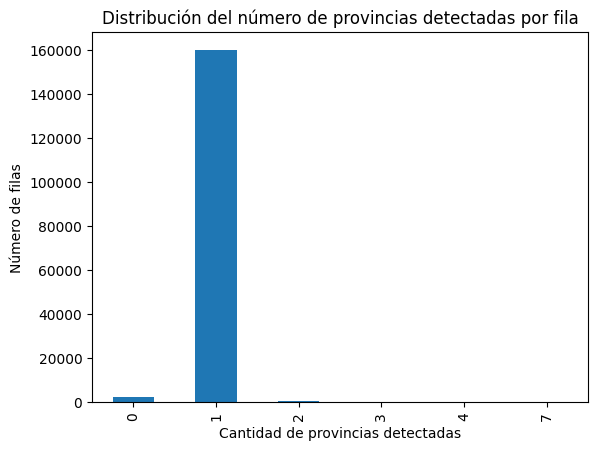

In [232]:
import matplotlib.pyplot as plt

df_provincias["Suma_provincias"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución del número de provincias detectadas por fila")
plt.xlabel("Cantidad de provincias detectadas")
plt.ylabel("Número de filas")
plt.show()


#### Distribución de universidades por provincia

Con el fin de analizar la cobertura territorial de las universidades mencionadas en los titulares del BOE, se generó una distribución por provincia.  
Cada universidad fue asociada a su provincia principal (sede central) para evitar duplicidades en el caso de instituciones con varios campus en distintas ciudades.

El siguiente análisis permite visualizar cuántas veces aparece cada provincia en el conjunto de datos, lo que proporciona una idea de la concentración administrativa y académica del sistema universitario español.  
Como se observa más adelante, provincias como Madrid, Barcelona, Valencia y Sevilla destacan por su alta frecuencia, lo que refleja su peso institucional y la presencia de universidades históricas o de gran tamaño.


,Número de menciones
Madrid,39573
Valencia,11876
Barcelona,9554
Sevilla,7644
Granada,7571
A Coruña,5307
Bizkaia,5284
Alicante,4980
Zaragoza,4863
Murcia,4417


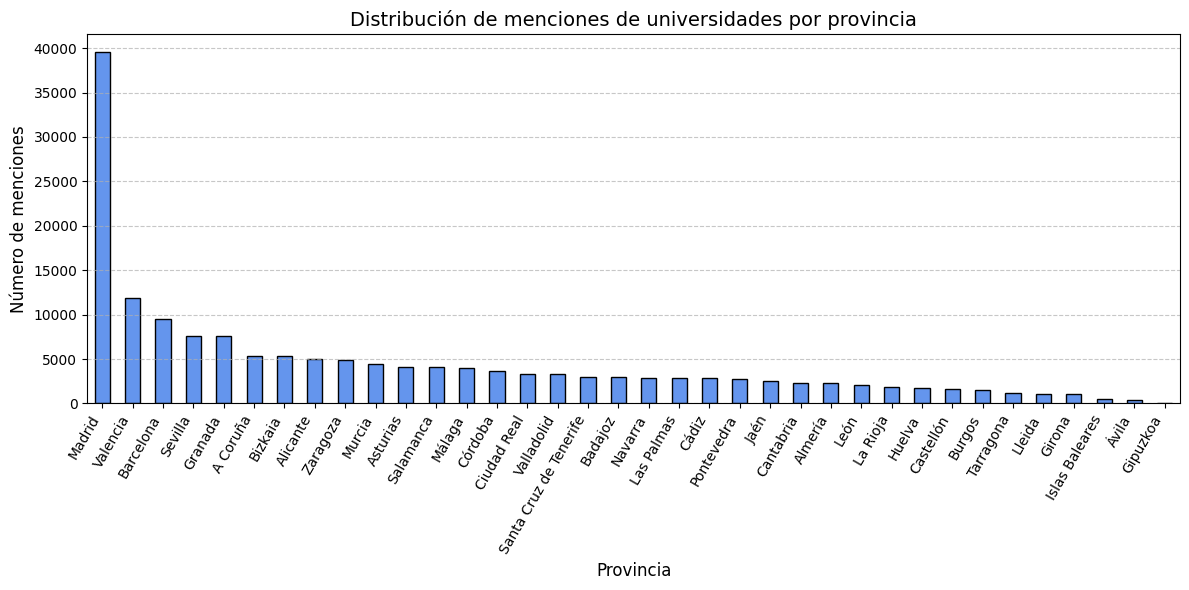

In [233]:
# Asegurarse de que solo tomamos las que existen en el CSV
columnas_presentes = [c for c in columnas_provincias if c in df_provincias.columns]

# Calcular el número de menciones por provincia
menciones_por_provincia = df_provincias[columnas_presentes].sum().sort_values(ascending=False)

# Mostrar tabla resumen
display(menciones_por_provincia.to_frame('Número de menciones'))

# Gráfico de barras
plt.figure(figsize=(12, 6))
menciones_por_provincia.plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Distribución de menciones de universidades por provincia', fontsize=14)
plt.xlabel('Provincia', fontsize=12)
plt.ylabel('Número de menciones', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
